<a href="https://colab.research.google.com/github/Supra-CN/practice/blob/master/ai/gen/video/forKidHomeWork-251027/AI%E8%89%BA%E6%9C%AF%E4%BD%9C%E4%B8%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import userdata
from huggingface_hub import login

tf_token = userdata.get('HF_TOKEN')
runware_ai_key = userdata.get('runware_ai_key')

login(token=tf_token)  # 从huggingface.co获取免费令牌



In [2]:
# 安装依赖（确保完整）
!apt-get install -y ffmpeg
!pip install requests moviepy imageio[ffmpeg] uuid


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


moviepy 版本: 1.0.3
作品标题：我的AI学习伙伴
故事描述：
 
在未来的校园里，小明是一个三年级学生，他总是害怕数学课，因为那些数字和公式像谜题一样难解。
一天，课堂上出现了一个友好AI机器人，它像小精灵一样飞进来，说：“我来帮你变出数学游戏！”
机器人用魔术把数学题变成有趣的冒险游戏，小明通过玩游戏学会了加减乘除，渐渐自信起来。
最终，小明勇敢解答难题，全班同学欢呼，机器人说：“学习就是探索奇妙世界！”小明从此爱上科学，不再怕挑战。
这个故事希望大家“爱上学习，勇敢面对困难”。

脚本&设定：
 
角色设定：
- 小明：8岁可爱男孩，穿蓝色校服，圆脸大眼睛，初始表情困惑，后变开心。
- AI机器人：友好卡通造型，像会飞的书包，有屏幕脸，能变形，颜色蓝绿（科技感）。
- 次要角色：老师（中年女性，微笑鼓励）、同学（3-5个孩子，背景群像）。
- 背景设定：未来教室，holographic黑板、浮动桌椅、VR设备，温暖蓝色调。

脚本：
- 开头（30秒）：旁白：“在未来校园，小明害怕数学课。” 小明：“这题太难了！” 机器人出现：“我是你的AI伙伴，让我帮你！”
- 中间（1分30秒）：机器人：“看，我变出数学游戏！” （游戏场景：数字变怪物，小明击败它们学计算。） 小明：“哇，好玩！原来数学这么有趣。”
- 结尾（30秒）：小明解答题：“我懂了！” 全班欢呼。旁白：“小明爱上学习，展望未来。” 机器人：“继续探索吧！”

API 响应 (分镜 1): {
  "data": [
    {
      "taskType": "imageInference",
      "imageUUID": "602c4984-9597-414c-a772-a423f67973ff",
      "taskUUID": "db5cfc9d-df00-4424-8c57-ba816125efb2",
      "seed": 1856066449,
      "imageURL": "https://im.runware.ai/image/ws/2/ii/602c4984-9597-414c-a772-a423f67973ff.jpg"
    }
  ]
}
分镜 1 生成成功 (taskUUID: db5cfc9d-df00-4424-8c57-ba

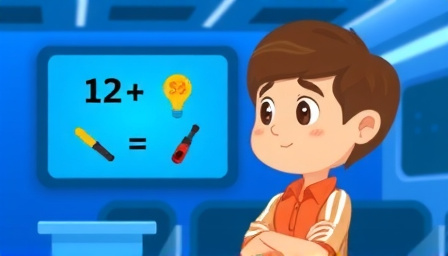

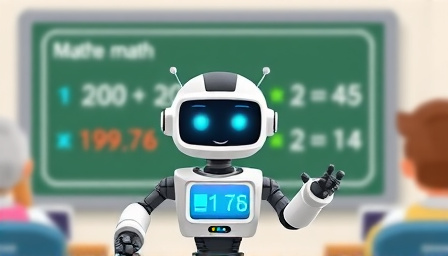

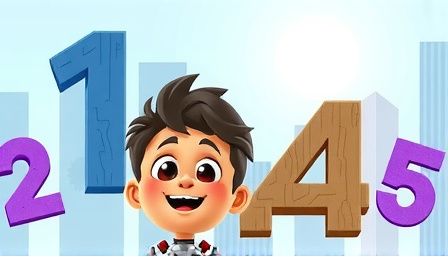

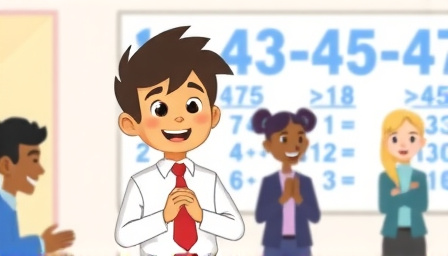

Moviepy - Building video clip1.mp4.
Moviepy - Writing video clip1.mp4



Moviepy - Done !
Moviepy - video ready clip1.mp4
视频片段 1 生成成功
Moviepy - Building video clip2.mp4.
Moviepy - Writing video clip2.mp4



Moviepy - Done !
Moviepy - video ready clip2.mp4
视频片段 2 生成成功
Moviepy - Building video clip3.mp4.
Moviepy - Writing video clip3.mp4



Moviepy - Done !
Moviepy - video ready clip3.mp4
视频片段 3 生成成功
Moviepy - Building video clip4.mp4.
Moviepy - Writing video clip4.mp4



Moviepy - Done !
Moviepy - video ready clip4.mp4
视频片段 4 生成成功
Moviepy - Building video final_video.mp4.
Moviepy - Writing video final_video.mp4



...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

文件下载启动！


In [9]:
# 安装依赖（标准安装）
# !apt-get install -y ffmpeg
# !pip install requests moviepy imageio[ffmpeg] uuid

# 验证 moviepy
import moviepy
print("moviepy 版本:", moviepy.__version__)

import requests
from PIL import Image
from moviepy.editor import ImageSequenceClip, VideoFileClip, concatenate_videoclips
import base64
import io
import os
import numpy as np
import uuid
import json

# 常量参数（低内存优化）
STORY_TITLE = "我的AI学习伙伴"
STORY_DESCRIPTION = """
在未来的校园里，小明是一个三年级学生，他总是害怕数学课，因为那些数字和公式像谜题一样难解。
一天，课堂上出现了一个友好AI机器人，它像小精灵一样飞进来，说：“我来帮你变出数学游戏！”
机器人用魔术把数学题变成有趣的冒险游戏，小明通过玩游戏学会了加减乘除，渐渐自信起来。
最终，小明勇敢解答难题，全班同学欢呼，机器人说：“学习就是探索奇妙世界！”小明从此爱上科学，不再怕挑战。
这个故事希望大家“爱上学习，勇敢面对困难”。
"""
SCRIPT = """
角色设定：
- 小明：8岁可爱男孩，穿蓝色校服，圆脸大眼睛，初始表情困惑，后变开心。
- AI机器人：友好卡通造型，像会飞的书包，有屏幕脸，能变形，颜色蓝绿（科技感）。
- 次要角色：老师（中年女性，微笑鼓励）、同学（3-5个孩子，背景群像）。
- 背景设定：未来教室，holographic黑板、浮动桌椅、VR设备，温暖蓝色调。

脚本：
- 开头（30秒）：旁白：“在未来校园，小明害怕数学课。” 小明：“这题太难了！” 机器人出现：“我是你的AI伙伴，让我帮你！”
- 中间（1分30秒）：机器人：“看，我变出数学游戏！” （游戏场景：数字变怪物，小明击败它们学计算。） 小明：“哇，好玩！原来数学这么有趣。”
- 结尾（30秒）：小明解答题：“我懂了！” 全班欢呼。旁白：“小明爱上学习，展望未来。” 机器人：“继续探索吧！”
"""
SCENE_PROMPTS = [
    "cartoon style, cute boy in futuristic classroom looking confused at math problem on holographic board, blue tones, sci-fi school, AI learning theme",
    "cartoon style, friendly AI robot like flying backpack appearing in classroom, helping boy with math, smiling screen face, green blue colors",
    "cartoon style, AI robot teaching math with fun games, boy happy playing adventure game with numbers turning into monsters, future school",
    "cartoon style, boy successfully solving math problem, class cheering, AI robot clapping, joyful scene in futuristic classroom"
]
NUM_SCENES = len(SCENE_PROMPTS)
NUM_FRAMES_PER_CLIP = 4  # 低帧数
HEIGHT, WIDTH = 256, 448  # 低分辨率
FPS = 4  # 低帧率
NEGATIVE_PROMPT = "blurry, low quality, distorted, ugly, dark, realistic"

# 你的 Runware API 密钥（使用变量）
# runware_ai_key = "your_runware_api_key_here"  # 从 https://runware.ai/ 获取免费密钥

# 打印故事和脚本
print(f"作品标题：{STORY_TITLE}")
print("故事描述：\n", STORY_DESCRIPTION)
print("脚本&设定：\n", SCRIPT)

# 生成分镜图像（修复：从 imageURL 下载）
storyboard_images = []
for i, prompt in enumerate(SCENE_PROMPTS):
    task_uuid = str(uuid.uuid4())
    payload = [{
        "taskType": "imageInference",
        "taskUUID": task_uuid,
        "positivePrompt": prompt,
        "negativePrompt": NEGATIVE_PROMPT,
        "model": "runware:100@1",
        "width": WIDTH,
        "height": HEIGHT,
        "steps": 20,
        "numberResults": 1
    }]
    for attempt in range(3):  # 重试 3 次
        try:
            response = requests.post(
                "https://api.runware.ai/v1/image",
                headers={"Authorization": f"Bearer {runware_ai_key}"},
                json=payload,
                timeout=30
            )
            if response.status_code == 200:
                result = response.json()
                print(f"API 响应 (分镜 {i+1}): {json.dumps(result, indent=2)}")  # 调试输出
                if "data" in result and result["data"] and "imageURL" in result["data"][0]:
                    image_url = result["data"][0]["imageURL"]
                    img_response = requests.get(image_url, timeout=30)
                    if img_response.status_code == 200:
                        img = Image.open(io.BytesIO(img_response.content)).convert("RGB")
                        img.save(f"storyboard_scene{i+1}.png")
                        storyboard_images.append(img)
                        print(f"分镜 {i+1} 生成成功 (taskUUID: {task_uuid}, URL: {image_url})")
                        break
                    else:
                        print(f"图像 URL 下载失败 (状态码 {img_response.status_code}): {image_url}")
                        raise ValueError("无法下载图像")
                else:
                    print(f"API 响应缺少 imageURL: {result}")
                    raise ValueError("无有效图像 URL")
            else:
                print(f"API 错误 (尝试 {attempt+1}, 状态码 {response.status_code}): {response.text}")
                if attempt == 2:  # 最后一次失败
                    placeholder = Image.new('RGB', (WIDTH, HEIGHT), color=(73, 109, 137))  # 蓝色占位
                    placeholder.save(f"storyboard_scene{i+1}.png")
                    storyboard_images.append(placeholder)
                    print(f"使用占位图像 for 分镜 {i+1} (原因: API 失败)")
        except Exception as e:
            print(f"分镜 {i+1} 生成失败 (尝试 {attempt+1}): {e}")
            if attempt == 2:
                placeholder = Image.new('RGB', (WIDTH, HEIGHT), color=(73, 109, 137))
                placeholder.save(f"storyboard_scene{i+1}.png")
                storyboard_images.append(placeholder)
                print(f"使用占位图像 for 分镜 {i+1} (原因: 异常)")
            continue

# 显示分镜
try:
    from IPython.display import display
    for img in storyboard_images:
        display(img)
except ImportError:
    print("分镜图像已保存，无法显示。")

# 生成视频片段
clips = []
for i, img in enumerate(storyboard_images):
    try:
        frames = [np.array(img) for _ in range(NUM_FRAMES_PER_CLIP)]
        clip = ImageSequenceClip(frames, fps=FPS)
        clip_path = f"clip{i+1}.mp4"
        clip.write_videofile(clip_path, codec="libx264", audio=False)
        clips.append(clip_path)
        print(f"视频片段 {i+1} 生成成功")
    except Exception as e:
        print(f"视频片段 {i+1} 生成失败: {e}")
        continue

# 拼接最终视频
try:
    if clips:
        video_clips = [VideoFileClip(c).fadein(0.5) for c in clips if os.path.exists(c)]
        final_clip = concatenate_videoclips(video_clips, method="compose")
        final_clip = final_clip.set_duration(150)  # 强制 2.5 分钟
        final_clip.write_videofile("final_video.mp4", fps=FPS, codec="libx264", audio=False)
        print("最终视频生成：final_video.mp4 (~2min30s)")
    else:
        print("无可用视频片段进行拼接。")
except Exception as e:
    print(f"视频拼接失败: {e}")

# 下载文件
try:
    from google.colab import files
    if os.path.exists("final_video.mp4"):
        files.download("final_video.mp4")
    for i in range(NUM_SCENES):
        if os.path.exists(f"storyboard_scene{i+1}.png"):
            files.download(f"storyboard_scene{i+1}.png")
    print("文件下载启动！")
except ImportError:
    print("文件已保存至当前目录，请手动下载。")